## SF Stencils

We follow:
- Seta, Amit, and Christoph Federrath. "Structure functions with higher-order stencils as a probe to separate small-and large-scale magnetic fields." Monthly Notices of the Royal Astronomical Society 533.2 (2024): 1875-1886.
- Cho, Jungyeon. "A technique for removing large-scale variations in regularly and irregularly spaced data." The Astrophysical Journal 874.1 (2019): 75.

and also include the methods to calculate higher-order stencils for SF calculations.

These higher-order stencils help to remove large-scale polynomial behaviour in the total field.

For our example, we generate a fluctuation field, and add a large-scale sinusoidal field.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import sys
import os
sys.path.insert(0, os.path.abspath('../../../'))
# Utility to make plots look nice
from kea.utils.plotting import modify_latex_rc, make_ax_step, pretty_axes
# modify_latex_rc()
# modify_latex_rc()

from kea.simulator import make_field

# Set number of grid points
N = 1024
# Number of dimensions (two-dimensional)
D = 1
# We have the same number of grid points in each dimension
grid_dims = (N,)*D

# Make the (fluctuation) field
d_field = make_field(grid_dims,
                   spectrum_kwargs={'powerlaw': -8./3., 'cutoff_scale': 5.},
                   spectrum_function='cutoff_powerlaw',
                   seed=1, normalize_output=True)
t = np.arange(N)
mean_field = 10.*np.sin(t/128.)
total_field = mean_field + d_field

The total field is the sum of the fluctuations and the large-scale sinusoidal motions.

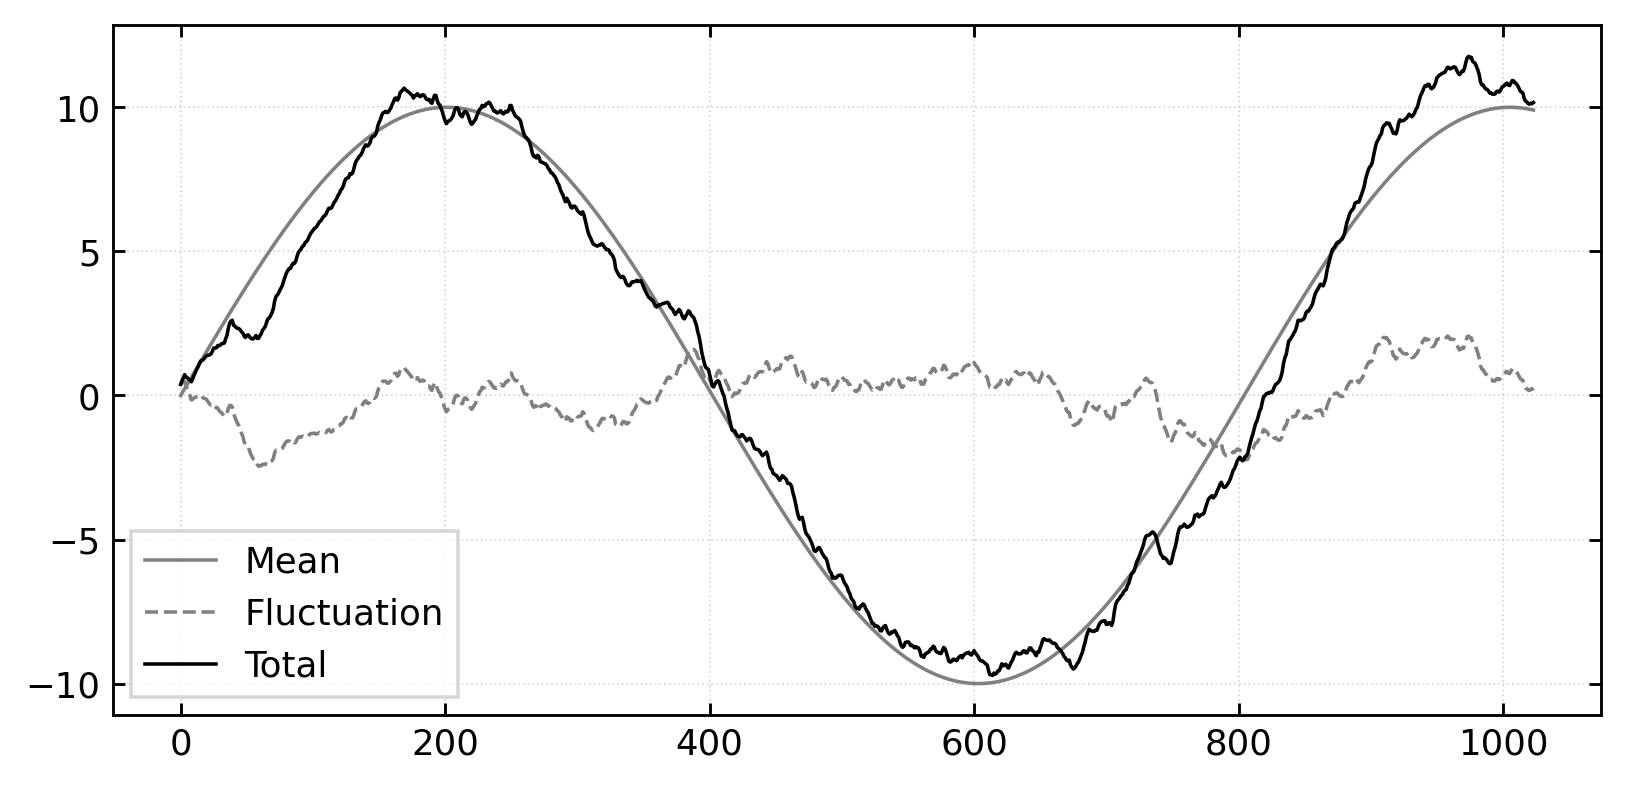

In [2]:
## Plot
fig, ax = plt.subplots(1, 1, figsize=(7.5, 3.5), dpi=256)

ax.plot(t, mean_field, color='gray', linestyle='-', linewidth=1., label='Mean')
ax.plot(t, d_field, color='gray', linestyle='--', linewidth=1., label='Fluctuation')
ax.plot(t, total_field, color='black', linestyle='-', linewidth=1., label='Total')

pretty_axes(ax)
ax.legend(fancybox=False, frameon=True)


Then, we calculate the n-pt SFs using the `n_pt` parameter.

For showcase, we calculate the SFs for the fluctuations only, as well as the total field (fluctuations + mean field).

In [3]:
from kea.statistics.statfunc import structure_function

ell, sf_d = structure_function(d_field, n_pt=2)
ell, sf_d3pt = structure_function(d_field, n_pt=3)

ell, sf2pt = structure_function(total_field, n_pt=2)
ell, sf3pt = structure_function(total_field, n_pt=3)
ell, sf4pt = structure_function(total_field, n_pt=4)
ell, sf5pt = structure_function(total_field, n_pt=5)

The result is shown below. The 2 point SF (blue) that includes the mean components varies significantly in slope, variance, and correlation scale when compared to the 2 point SF of the fluctuations alone (black dashed).

Whereas the 3,4,5 point SFs of the total field better match the 2,3 point SFs of the fluctuations.

(0.0001, 400.0)

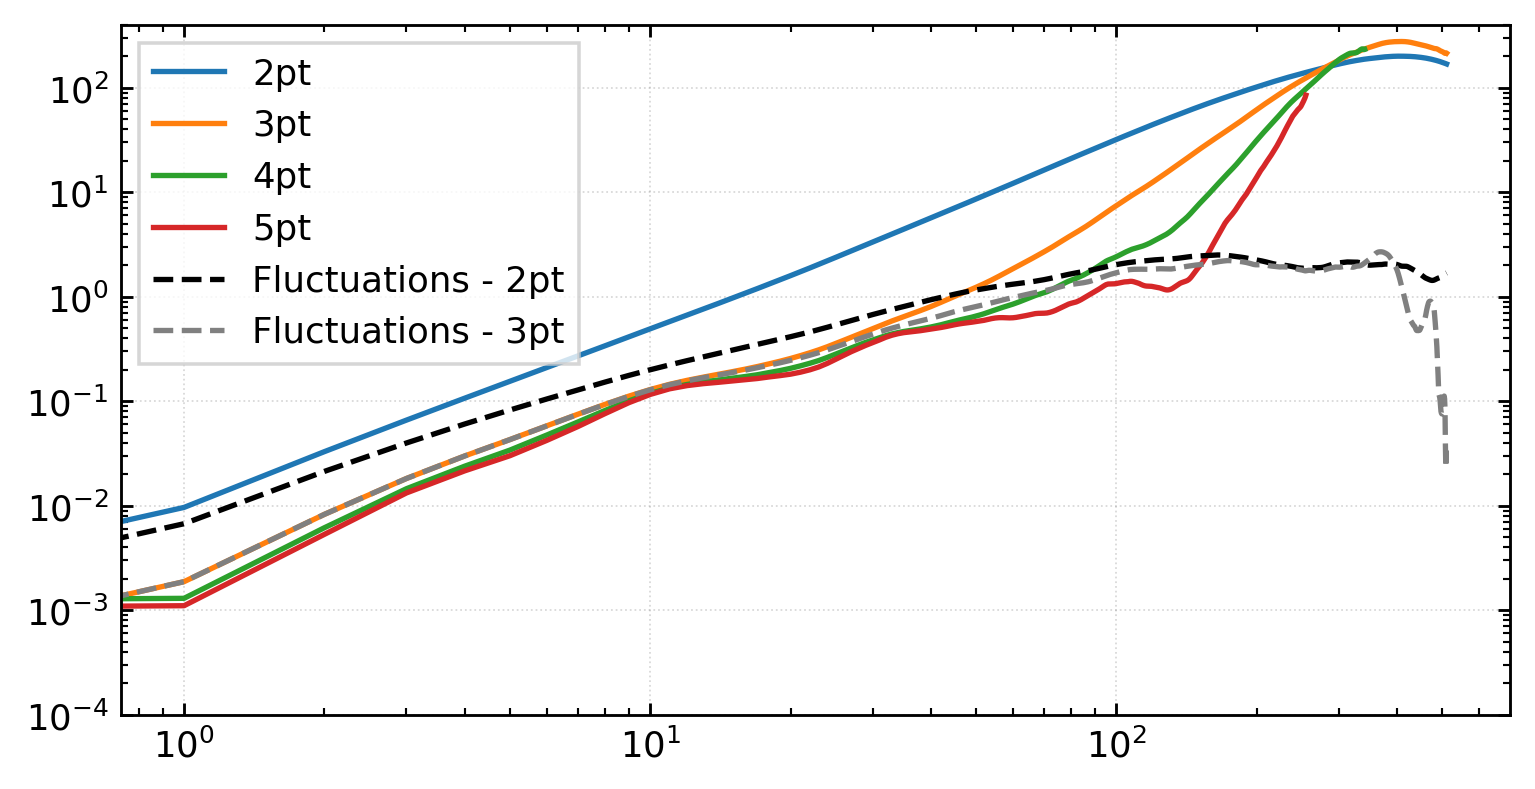

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(7., 3.5), dpi=256)

ax.plot(ell, sf2pt, linestyle='-', label='2pt')
ax.plot(ell, sf3pt, linestyle='-', label='3pt')
ax.plot(ell, sf4pt, linestyle='-', label='4pt')
ax.plot(ell, sf5pt, linestyle='-', label='5pt')

ax.plot(ell, sf_d, linestyle='--', color='black', label='Fluctuations - 2pt')
ax.plot(ell, sf_d3pt, linestyle='--', color='gray', label='Fluctuations - 3pt')

ax.legend(fancybox=False)

ax.set_yscale('log')
ax.set_xscale('log')
pretty_axes(ax)
ax.set_ylim((1e-4, 4e2))
